In [94]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
import tensorflow as tf

In [220]:
# Load Data (excluding behavioural neurons) and plot
worm_num = 0
algorithm = 'BunDLeNet'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = 'datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
#mask = data.categorise_neurons('datasets/raw/c_elegans')
X = data.neuron_traces.T
B = data.behaviour


In [221]:
### Preprocess and prepare data for BundLe Net
# time, X = preprocess_data(X, data.fps)
X_, B_ = prep_data(X, B, win=15)

# Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names))
model.T_Y = tf.keras.Sequential([
            tf.keras.layers.Dense(3, activation='relu'),
            tf.keras.layers.Dense(3, activation='relu'),
            tf.keras.layers.Dense(6, activation='relu'),
            tf.keras.layers.Dense(3, activation='relu'),
            tf.keras.layers.Dense(3, activation='linear'),

        ])

In [222]:
loss_array, _ = train_model(
    X_,
    B_,
    model,
    b_type='discrete',
    gamma=0.0,
    learning_rate=0.001,
    n_epochs=500,
    # initialisation='best_of_5_init'
)

loss_array[-1,:]

Loss [Markov, Behaviour, Total]: [0.     0.2931 0.2931]: 100%|█████| 500/500 [01:11<00:00,  7.02it/s]


array([0.        , 0.29309193, 0.29309193])

In [223]:
loss_array[-1,0]

0.0

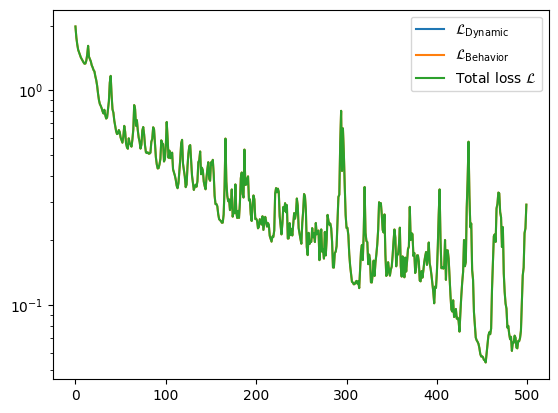

In [224]:
%matplotlib inline
plt.figure()
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Dynamic}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

In [225]:
yt1_upper = model.tau(X_[:,1])

yt_lower = model.tau(X_[:, 0])
yt1_lower = yt_lower + model.T_Y(yt_lower)

from sklearn.metrics import mean_squared_error
mean_squared_error(yt1_upper, yt1_lower)

3.6826456

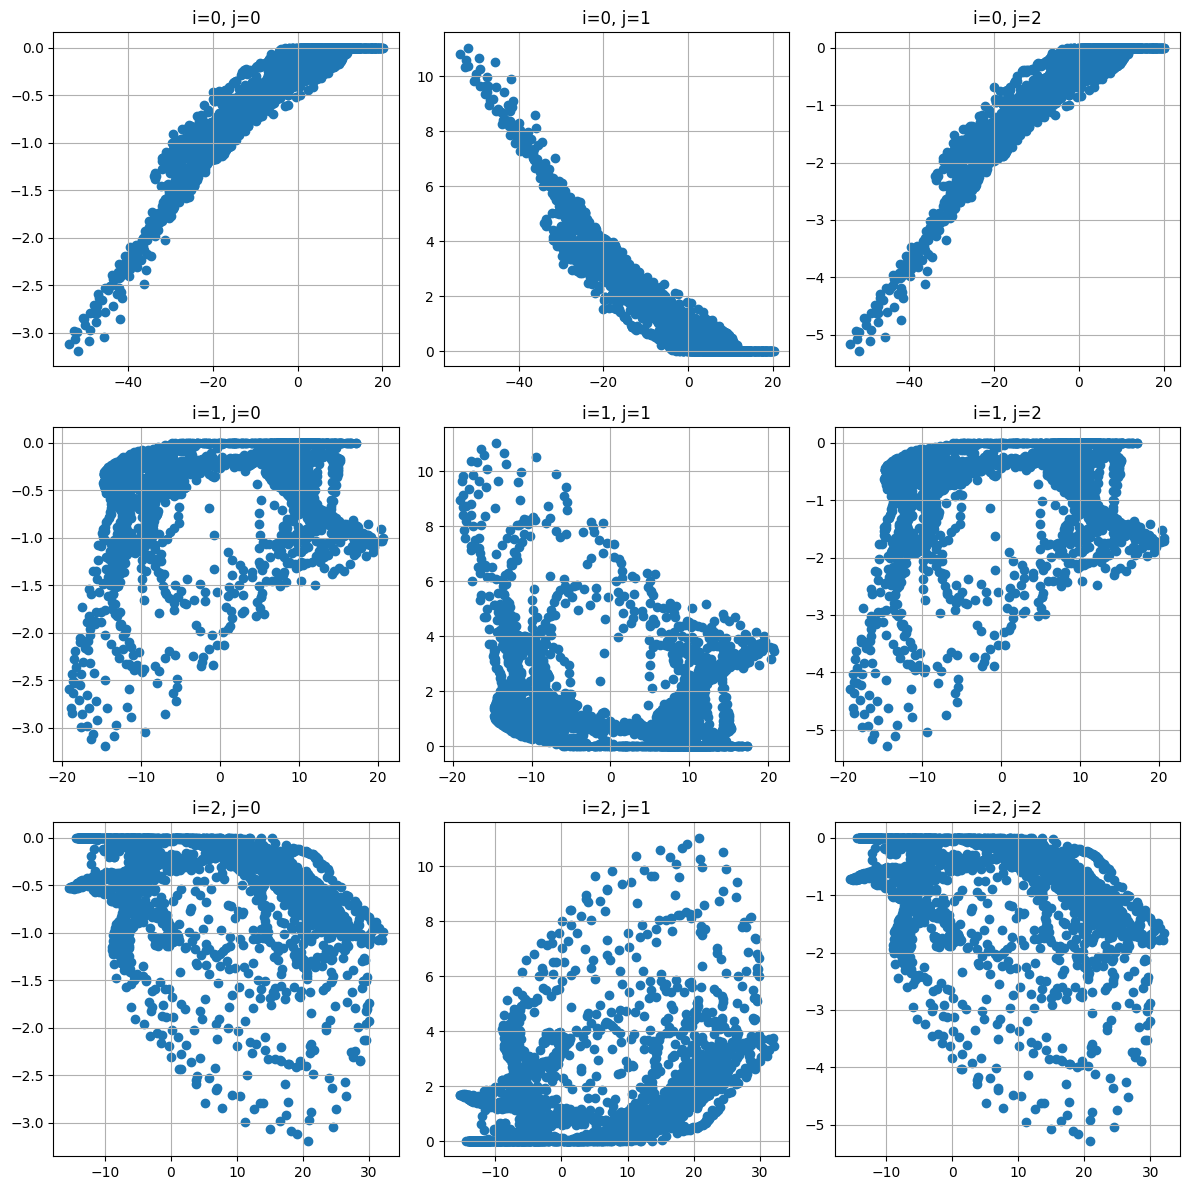

In [226]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):
        axes[i, j].scatter(yt1_upper[:, i], model.T_Y(yt1_lower)[:, j])
        axes[i, j].grid()
        axes[i, j].set_title(f'i={i}, j={j}')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


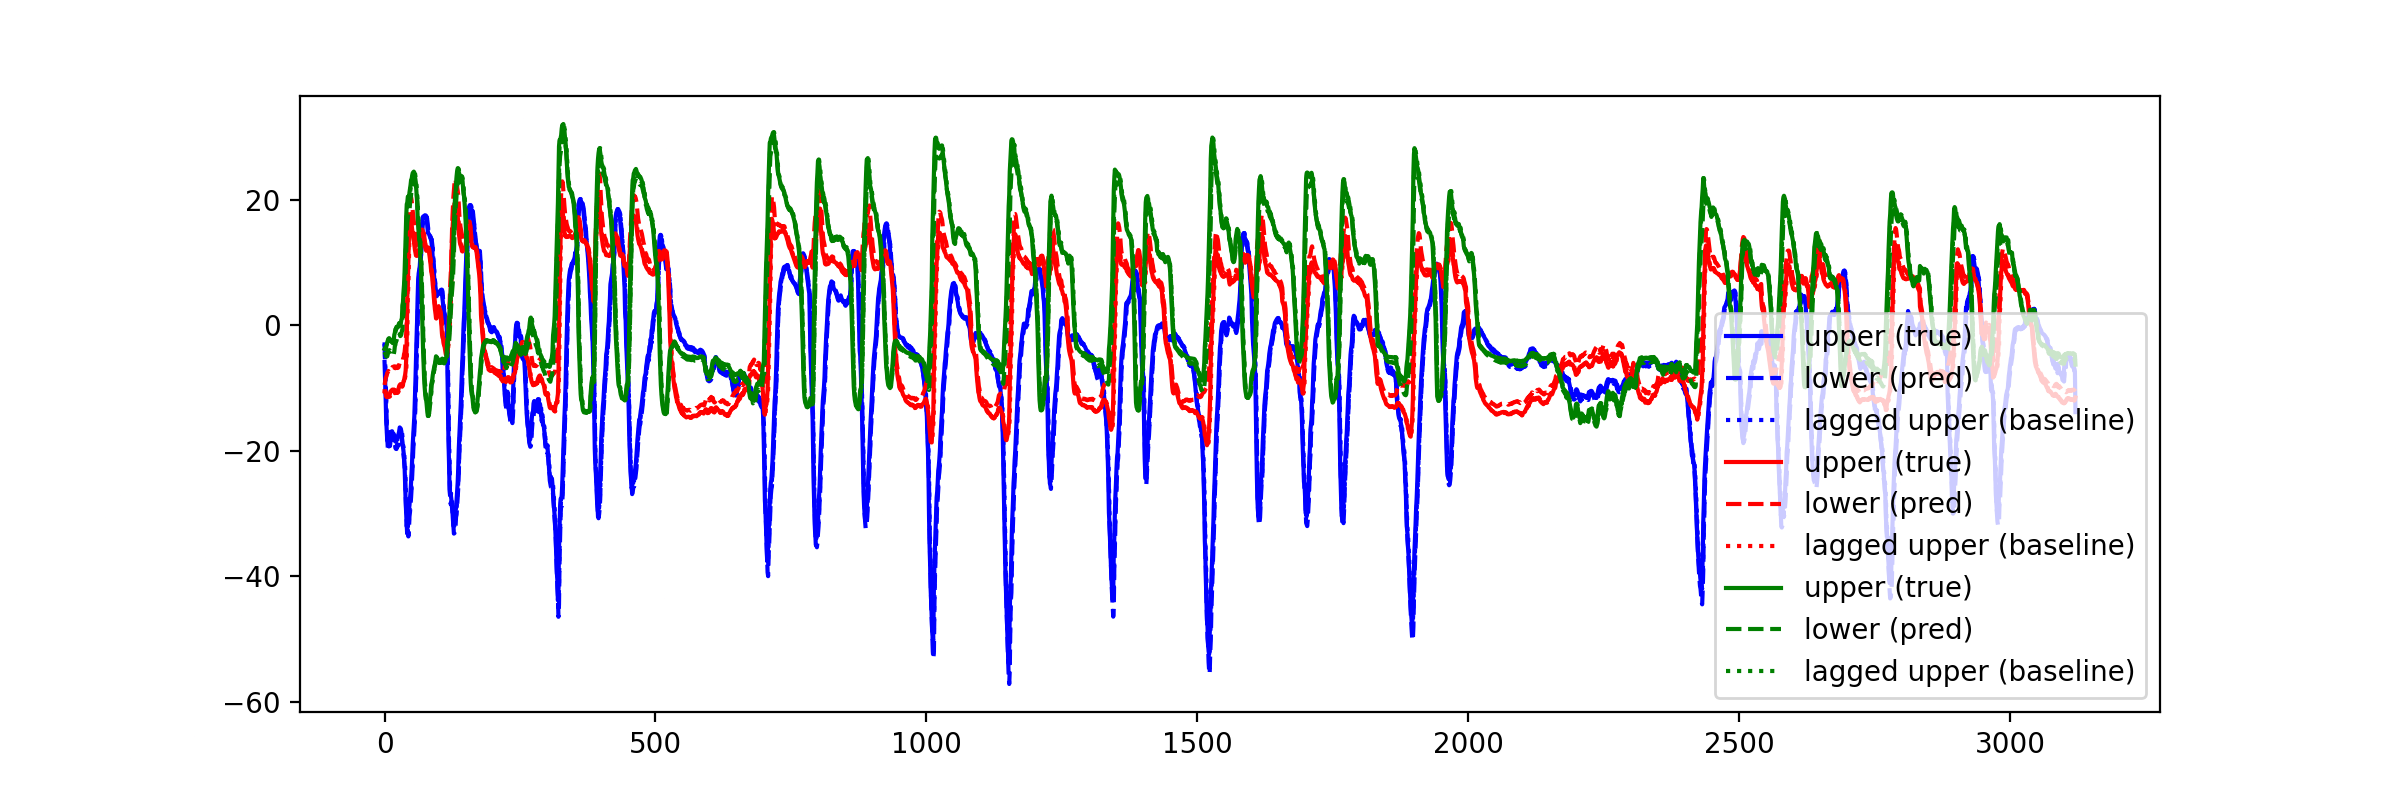

In [227]:
%matplotlib notebook
plt.figure(figsize=(12,4))
color = ['b', 'r', 'g']
for i in range(3):
    
    plt.plot(yt1_upper[:,i], label='upper (true)', color=color[i])
    plt.plot(yt1_lower[:,i], label='lower (pred)', color=color[i], linestyle='--')
    plt.plot(yt_lower[:,i], label='lagged upper (baseline)', color=color[i], linestyle=':')
    # plt.plot(10+100*model.T_Y(yt_lower))

    plt.legend()


<IPython.core.display.Javascript object>


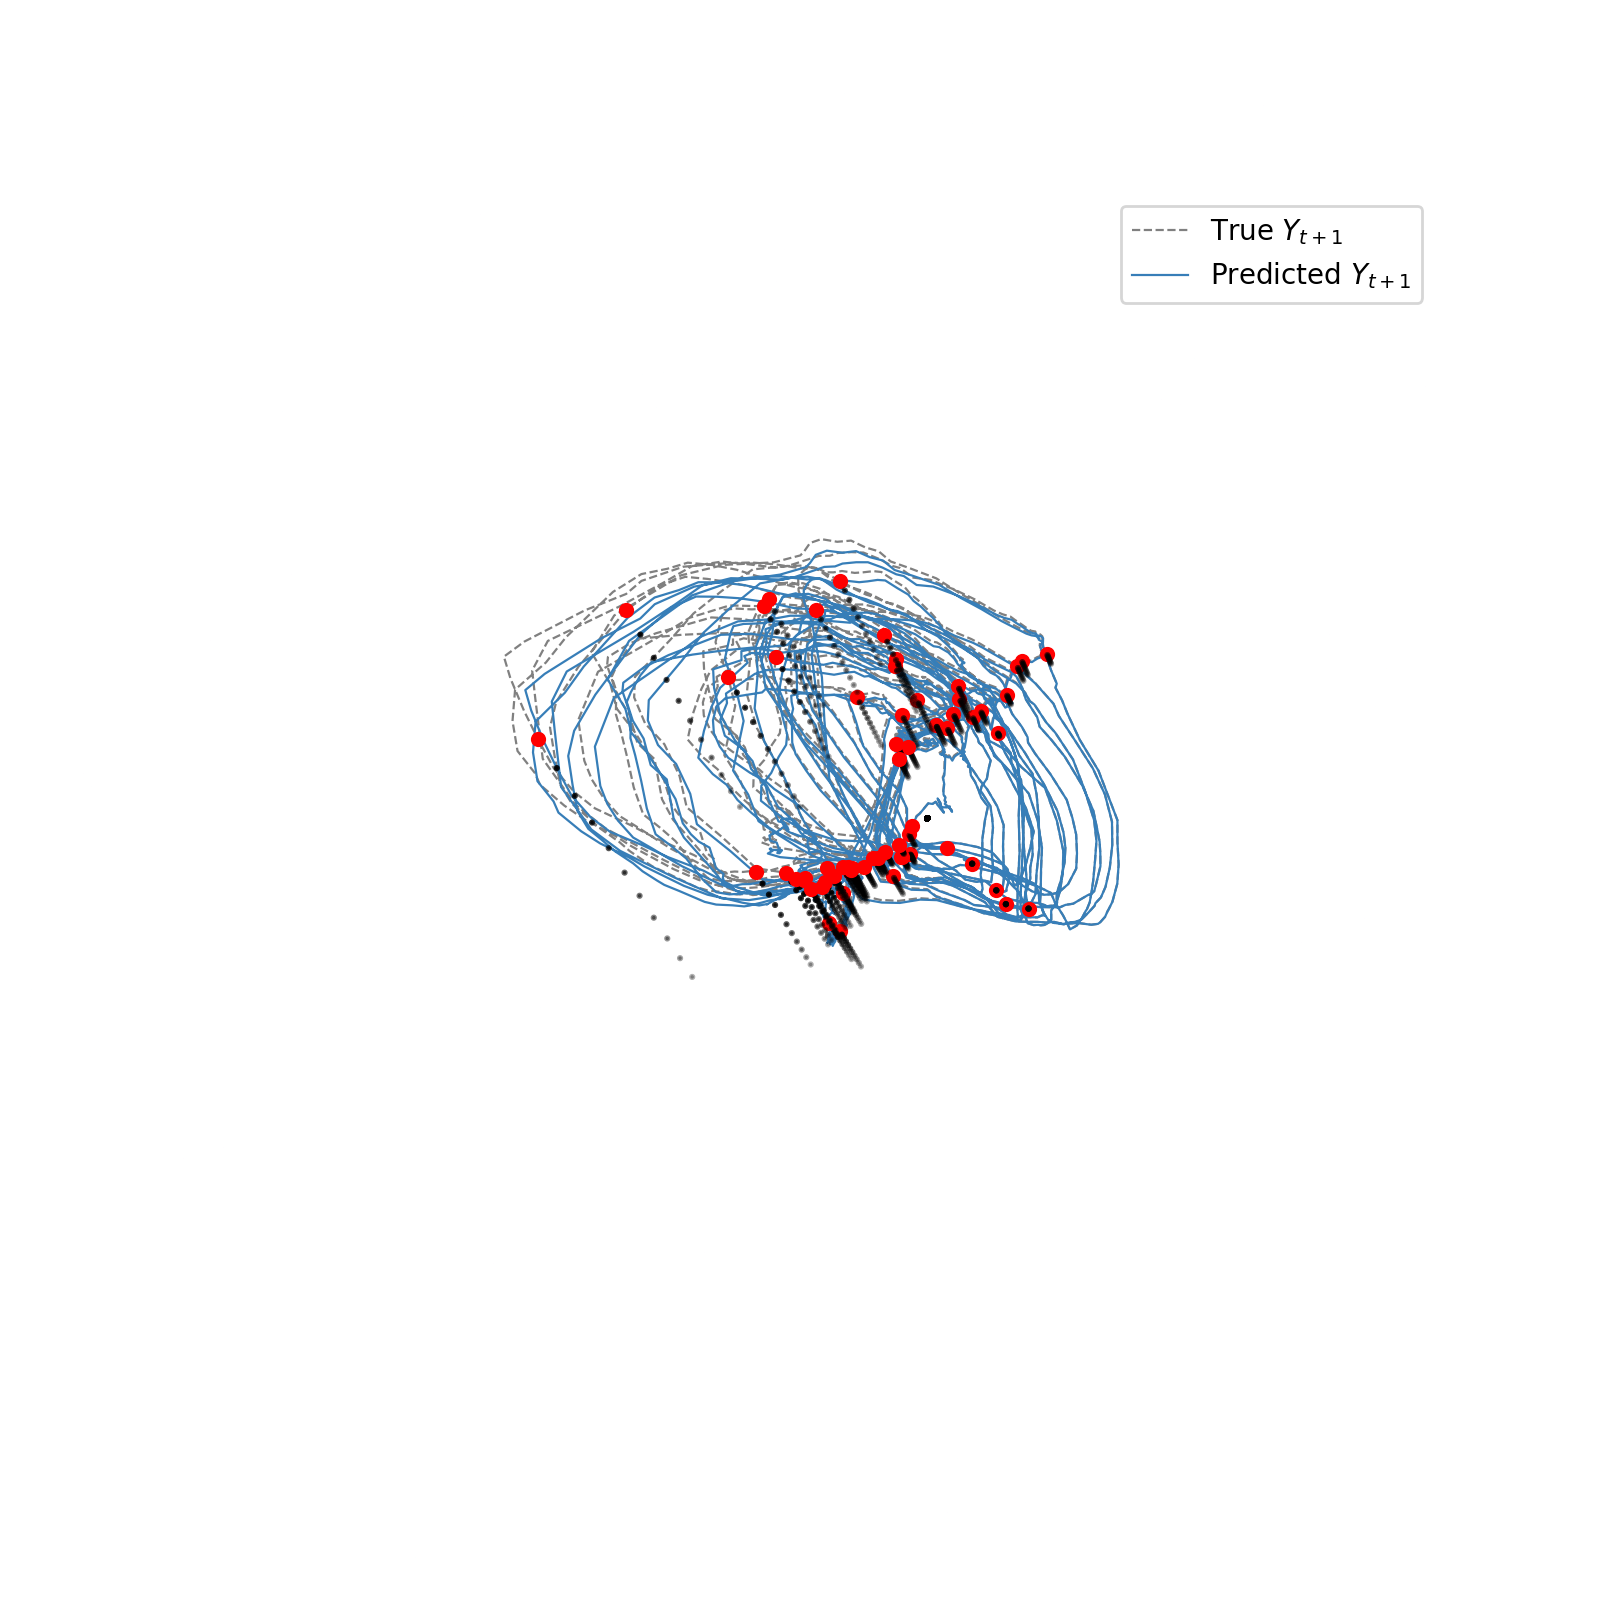

In [228]:
Y0_ = model.tau(X_[:,0]).numpy() # Y_t
Y1_ = model.tau(X_[:,1]).numpy()
Y1_pred = Y0_ + model.T_Y(Y0_).numpy()


fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
ax.view_init(elev=37, azim=177, roll=0)
true_y_line = ax.plot(Y1_[:, 0], Y1_[:, 1], Y1_[:, 2], color='gray', linewidth=.8, linestyle='--', label=r'True $Y_{t+1}$') 
predicted_y_line = ax.plot(Y1_pred[:, 0], Y1_pred[:, 1], Y1_pred[:, 2], color='#377eb8',  linewidth=.8,  label=r'Predicted $Y_{t+1}$')
ax.set_axis_off()  
plt.legend(handles=[true_y_line[0], predicted_y_line[0]])


## Time evolution for some chosen points 
t_steps = 10
for i in np.arange(0,Y0_.shape[0], 50):
	y_start = Y0_[i]
	y_t = y_start
	Y_evolved = np.zeros((100,3))
	for i in range(t_steps):
		y_t = y_t + model.T_Y(y_t.reshape(1,3)).numpy()
		Y_evolved[i] = y_t[0]
	ax.scatter(y_start[0], y_start[1], y_start[2], c='r')
	evolved_y_line = ax.scatter(Y_evolved[:, 0], Y_evolved[:, 1], Y_evolved[:, 2], color='k', s=1.5,  label=r'Simulated $Y_{t+1}$')

ax.set_axis_off()  
plt.legend(handles=[true_y_line[0], predicted_y_line[0]])
plt.show()

<IPython.core.display.Javascript object>


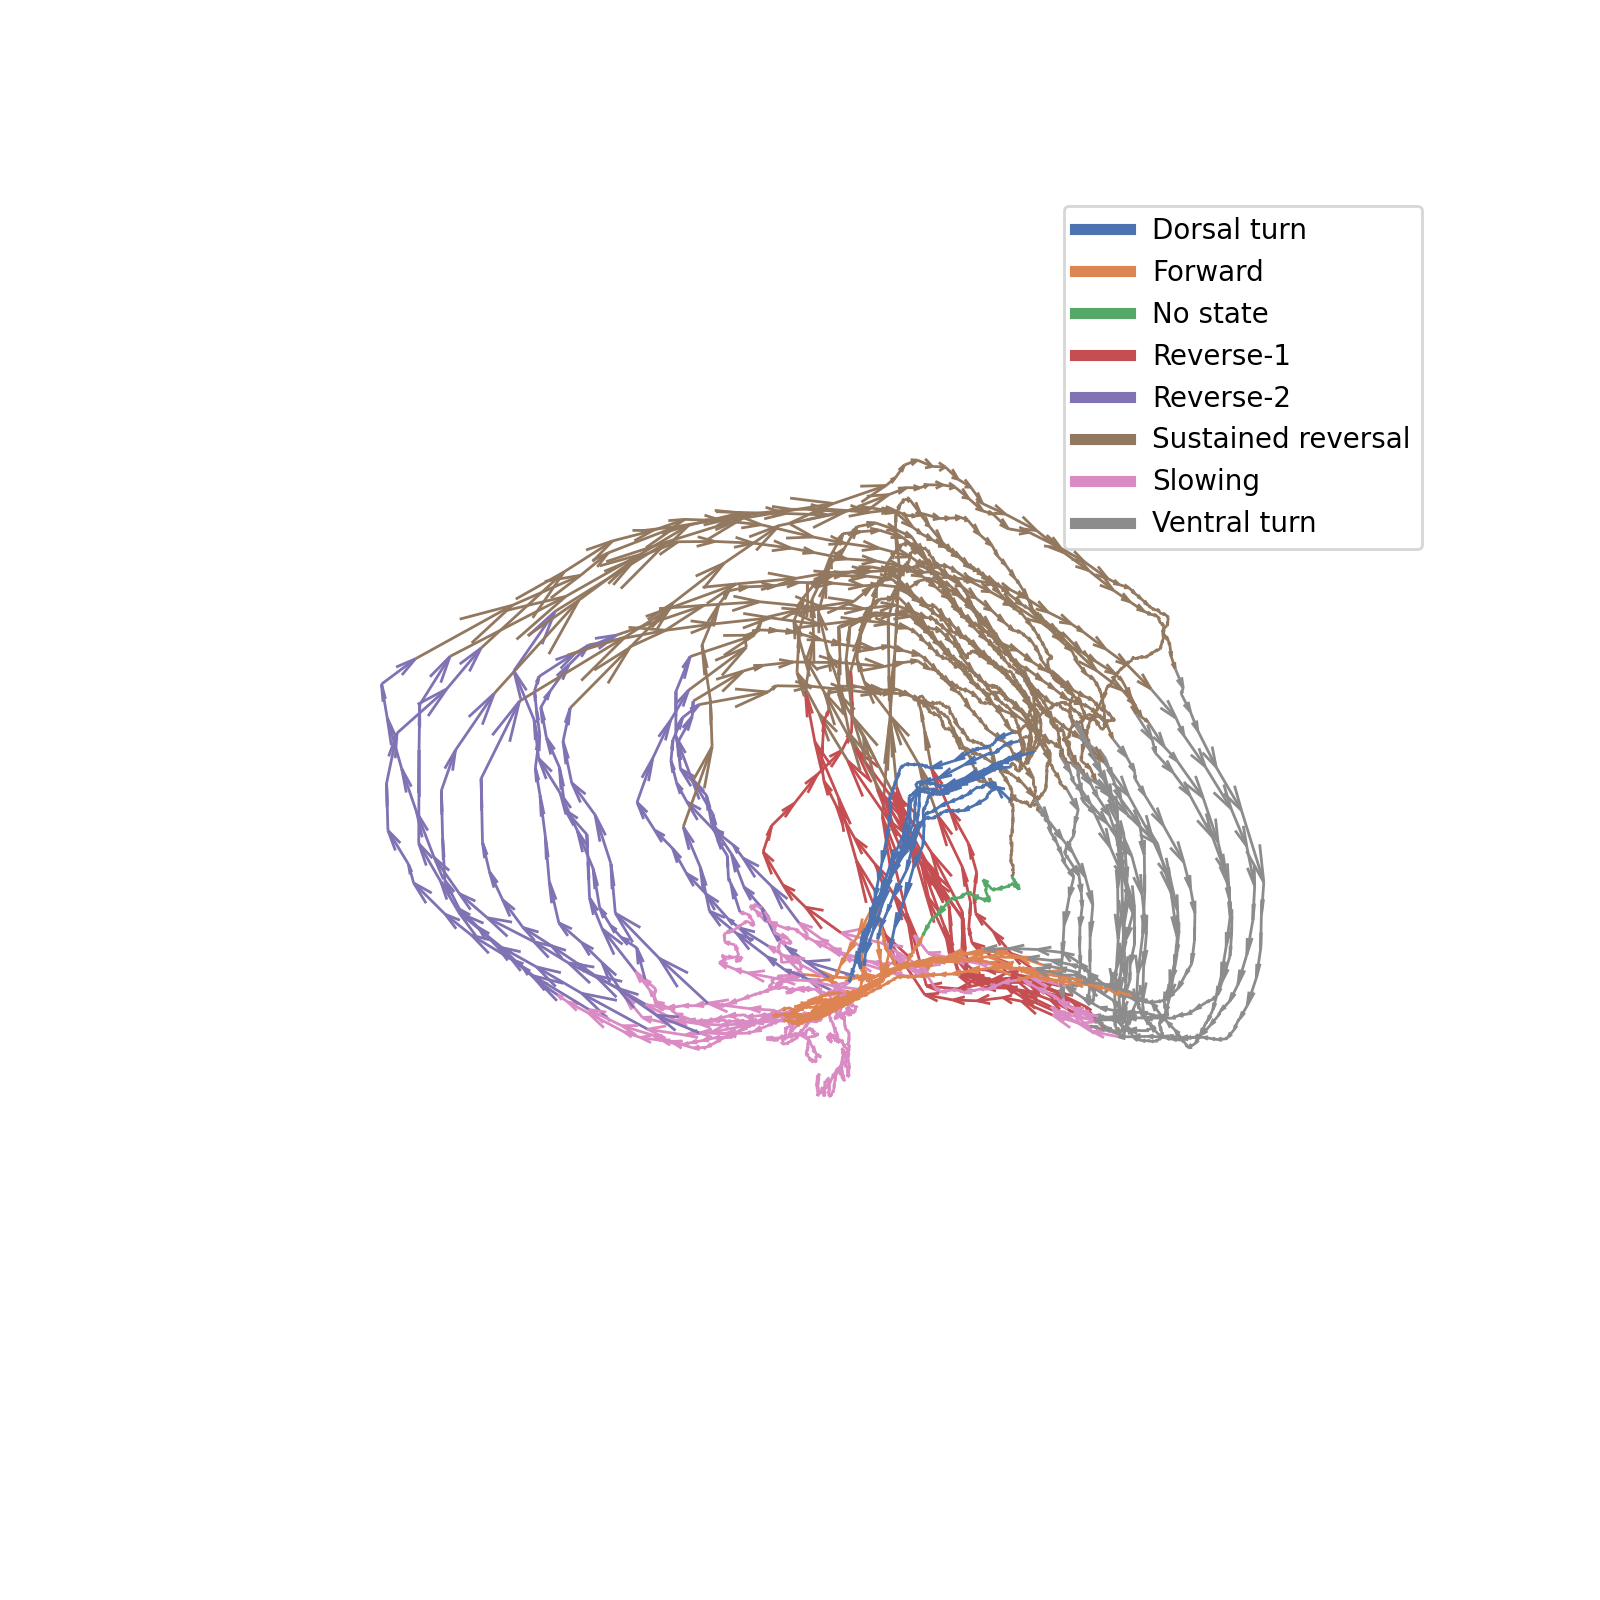

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [233]:
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

# Plotting latent space dynamics
vis = LatentSpaceVisualiser(Y0_, B_, data.behaviour_names)
vis.plot_phase_space(arrow_length_ratio=0.5)


In [229]:
np.arange(0,Y0_.shape[0], 1000)

array([   0, 1000, 2000, 3000])

In [6]:
    yt1_upper = self.tau(x[:, 1])
    bt1_upper = self.predictor(yt1_upper)

    # Lower arm of commutativity diagram
    yt_lower = self.tau(x[:, 0])
    yt1_lower = yt_lower + self.T_Y(yt_lower)

array([0.00724596, 0.0676468 , 0.07489276])